# Problem Definition



## **Konteks Permasalahan**
Banyak UMKM memiliki produk yang potensial, namun seringkali kesulitan mendapatkan akses pendanaan dari investor. Masalah utamanya adalah:
* **Asimetri Informasi:** Investor sulit memvalidasi performa bisnis UMKM hanya dari presentasi verbal.
* **Standarisasi Data:** Belum adanya platform yang menyajikan performa finansial dan operasional UMKM secara transparan dan berbasis data.

### **Analisis Masalah**
Dari berbagai kendala tersebut, titik temunya adalah perlunya sebuah media yang mampu mengubah data transaksi mentah menjadi informasi strategis yang menunjukkan skalabilitas bisnis (scalability) dan kesehatan finansial (business health).

### **Solusi Utama yang Dikembangkan**
Proyek ini mengembangkan **"SME Investment-Ready Dashboard"**. Solusi ini bertujuan untuk:
1. Menampilkan visualisasi performa UMKM secara.
2. Membantu UMKM melakukan *pitching* berbasis data (data-driven pitching).
3. Memberikan transparansi data bagi investor untuk menilai kelayakan investasi berdasarkan metrik pertumbuhan yang terukur.

# Business Understanding

## Pertanyaan

Pertanyaan 1: Berapa banyak UMKM yang masuk dalam kategori Class: Growth yang memiliki Net_Profit_Margin (%) di atas 15% serta Monthly_Revenue di atas rata-rata keseluruhan?

Pertanyaan 2: Bagaimana perbandingan rata-rata Repeat_Order_Rate (%) antara UMKM yang sudah beroperasi di atas 24 bulan (Business_Tenure_Months) dengan yang di bawah 24 bulan?

Pertanyaan 3: Bagaimana karakteristik performa lintas variabel (finansial, operasional, dan perilaku pelanggan) yang membedakan kelas Growth, Elite, Critcial dan Struggling secara signifikan?

# Import Library

In [1]:
import gdown
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.stats import f_oneway

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from statsmodels.stats.outliers_influence import variance_inflation_factor

import joblib

# Data Wrangling

## Data Gathering

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = '/content/drive/MyDrive/Capstone/UMKM_2_extended_dirty.csv'
df = pd.read_csv(path)

/tmp/ipykernel_6875/3233932669.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [4]:
df.head()

,ID,Monthly_Revenue,Net_Profit_Margin (%),Burn_Rate_Ratio,Transaction_Count,Avg_Historical_Rating,Review_Text,Review_Volatility,Business_Tenure_Months,Repeat_Order_Rate (%),Digital_Adoption_Score,Peak_Hour_Latency,Location_Competitiveness,Sentiment_Score,Class
0,1,6680716.0,22.72,0.811,161,4.75,"Transaksi digital lancar, proses checkout tida...",0.313,105,19.40,4.24,Low,9,-0.25,Growth
1,2,5819101.0,4.46,0.968,104,4.21,"Harga dan kualitas seimbang, pengalaman biasa ...",0.632,95,14.87,1.27,Med,10,0.00,Growth
2,3,5236404.0,-10.12,1.047,102,3.51,"Pelayanan standar, masih bisa ditingkatkan.",0.470,17,21.00,3.37,Med,8,0.00,Struggling
3,4,8043552.0,0.04,0.969,99,4.33,"Transaksi digital lancar, proses checkout tida...",0.206,109,30.62,5.41,Low,13,-0.25,Growth
4,5,6071256.0,4.22,0.954,115,4.34,Selalu repeat order karena kualitasnya terjaga...,0.232,74,20.87,2.67,Low,7,0.25,Growth


**Insight :**

Dari hasil data gathering yang ditampilkan, terlihat bahwa tidak semua bisnis dengan revenue tinggi memiliki kondisi keuangan yang sehat. Beberapa data menunjukkan bahwa meskipun pendapatan bulanan cukup besar, nilai net profit margin bisa sangat rendah bahkan negatif, yang mengindikasikan adanya inefisiensi operasional atau biaya yang terlalu tinggi. Hal ini diperkuat oleh nilai burn rate ratio yang tinggi pada beberapa bisnis, yang menunjukkan bahwa pengeluaran mereka lebih besar dibanding pemasukan sehingga berisiko mengalami kerugian.

Selain itu, tingkat kepuasan pelanggan yang tercermin dari rating tidak selalu berbanding lurus dengan profitabilitas. Terdapat bisnis dengan rating tinggi namun margin keuntungannya sangat kecil, yang kemungkinan disebabkan oleh strategi seperti pemberian diskon atau biaya operasional yang besar. Di sisi lain, repeat order rate terlihat menjadi salah satu faktor penting dalam mendorong pertumbuhan bisnis, di mana bisnis dengan tingkat pembelian ulang yang tinggi cenderung masuk ke kategori growth.

Adopsi digital juga menunjukkan pengaruh terhadap performa bisnis. Bisnis dengan digital adoption score yang lebih tinggi cenderung memiliki operasional yang lebih efisien dan margin yang lebih baik dibandingkan dengan bisnis yang masih rendah dalam pemanfaatan teknologi. Sementara itu, faktor operasional seperti latency dan tingkat kompetisi lokasi turut memberikan dampak terhadap kinerja bisnis, meskipun tidak selalu menjadi penentu utama.

Secara keseluruhan, dapat disimpulkan bahwa keberhasilan bisnis tidak hanya ditentukan oleh besarnya revenue, tetapi juga oleh efisiensi operasional, kemampuan mempertahankan pelanggan, serta pemanfaatan teknologi digital.


## Data Asessing

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150010 entries, 0 to 150009
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        150010 non-null  int64  
 1   Monthly_Revenue           150009 non-null  float64
 2   Net_Profit_Margin (%)     150010 non-null  float64
 3   Burn_Rate_Ratio           150010 non-null  float64
 4   Transaction_Count         150010 non-null  object 
 5   Avg_Historical_Rating     150010 non-null  float64
 6   Review_Text               150009 non-null  object 
 7   Review_Volatility         150010 non-null  float64
 8   Business_Tenure_Months    150010 non-null  int64  
 9   Repeat_Order_Rate (%)     150010 non-null  float64
 10  Digital_Adoption_Score    150010 non-null  float64
 11  Peak_Hour_Latency         150010 non-null  object 
 12  Location_Competitiveness  150010 non-null  int64  
 13  Sentiment_Score           150010 non-null  f

In [6]:
df.describe()

,ID,Monthly_Revenue,Net_Profit_Margin (%),Burn_Rate_Ratio,Avg_Historical_Rating,Review_Volatility,Business_Tenure_Months,Repeat_Order_Rate (%),Digital_Adoption_Score,Location_Competitiveness,Sentiment_Score
count,150010.000000,1.500090e+05,150010.000000,150010.000000,150010.000000,150010.000000,150010.000000,150010.000000,150010.000000,150010.000000,150010.000000
mean,74999.606113,8.451636e+06,1.845875,0.969882,4.061115,0.407198,91.073455,19.980384,3.546903,8.998867,-0.018939
std,43302.003887,5.291113e+06,15.057280,0.144037,0.521691,0.166804,57.149382,8.021879,1.670308,2.828599,0.320534
min,1.000000,-1.000000e+06,-35.000000,0.437000,1.500000,0.060000,3.000000,2.000000,1.000000,1.000000,-0.650000
25%,37499.250000,4.745844e+06,-8.430000,0.869000,3.770000,0.278000,47.000000,14.450000,2.260000,7.000000,-0.250000
50%,74999.500000,7.245728e+06,2.160000,0.966000,4.100000,0.405000,91.000000,19.950000,3.480000,9.000000,0.000000
75%,112499.750000,1.083018e+07,12.310000,1.067000,4.410000,0.526000,135.000000,25.430000,4.690000,11.000000,0.000000
max,150000.000000,8.206754e+07,500.500000,1.550000,5.000000,0.990000,9999.000000,54.060000,10.000000,23.000000,0.800000


In [7]:
df.isna().sum()

,0
ID,0
Monthly_Revenue,1
Net_Profit_Margin (%),0
Burn_Rate_Ratio,0
Transaction_Count,0
Avg_Historical_Rating,0
Review_Text,1
Review_Volatility,0
Business_Tenure_Months,0
Repeat_Order_Rate (%),0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print(f"Jumlah baris pada dataset : {df.shape[0]}")
print(f"Jumlah kolom pada dataset : {df.shape[1]}")

Jumlah baris pada dataset : 150010
Jumlah kolom pada dataset : 15


**Insight :**

Dari hasil data assessing yang kami tampilkan, dapat disimpulkan bahwa dataset memiliki jumlah data yang sangat besar, yaitu lebih dari 150 ribu baris, sehingga cukup representatif untuk dilakukan analisis lebih lanjut. Secara umum, sebagian besar kolom sudah memiliki nilai yang lengkap, namun masih terdapat beberapa missing value pada kolom *Monthly_Revenue*, *Review_Text*, dan *Class*. Jumlah data yang hilang ini sangat kecil dibanding total data, sehingga keputusan untuk langsung menghapus sekitar 10 data kotor merupakan langkah yang tepat dan tidak akan memberikan dampak signifikan terhadap hasil analisis.

Dari sisi tipe data, terdapat beberapa ketidaksesuaian yang perlu diperbaiki, seperti kolom *Transaction_Count* dan *Peak_Hour_Latency* yang masih bertipe object padahal seharusnya berupa numerik. Hal ini menunjukkan adanya inkonsistensi format data yang perlu ditangani pada tahap data cleaning agar tidak mengganggu proses analisis atau pemodelan.

Jika dilihat dari statistik deskriptif, terdapat indikasi adanya outlier yang cukup ekstrem pada beberapa fitur. Misalnya, nilai maksimum *Net_Profit_Margin (%)* mencapai lebih dari 500%, yang secara logika bisnis tergolong tidak wajar. Selain itu, *Business_Tenure_Months* memiliki nilai maksimum hingga 9999 bulan, yang juga menunjukkan kemungkinan data tidak realistis. Nilai minimum *Monthly_Revenue* yang negatif juga menjadi indikasi adanya data yang tidak valid atau kesalahan pencatatan.

Distribusi data juga menunjukkan variasi yang cukup tinggi, terutama pada *Monthly_Revenue* dan *Net_Profit_Margin (%)*, yang terlihat dari nilai standar deviasi yang besar. Hal ini menandakan bahwa performa bisnis dalam dataset sangat beragam, mulai dari yang sangat rendah hingga sangat tinggi.

Secara keseluruhan, dataset ini sudah cukup siap untuk digunakan setelah dilakukan pembersihan sederhana, seperti menghapus data yang hilang, memperbaiki tipe data, serta menangani outlier yang tidak masuk akal. Dengan kualitas data yang relatif baik dan jumlah data yang besar, analisis yang dilakukan nantinya berpotensi menghasilkan insight yang kuat dan representatif.


## Data Cleaning

In [10]:

print(f"Jumlah data awal: {len(df)}")

# --- PROSES CLEANING ---

# Inisialisasi dataframe baru
df_cleaned = df.copy()
# 1. Menghapus baris yang memiliki nilai null pada kolom krusial
df_cleaned = df_cleaned.dropna(subset=['Monthly_Revenue', 'Class', 'Review_Text'])

# 2. Menghapus data dengan nilai yang tidak masuk akal (Outliers)
# Contoh: Monthly_Revenue negatif atau Net_Profit_Margin yang mustahil (>100%)
df_cleaned = df_cleaned[(df_cleaned['Monthly_Revenue'] >= 0) &
                        (df_cleaned['Net_Profit_Margin (%)'] <= 100)]

# 3. Menghapus data dengan tipe data campuran (Misal: Transaction_Count yang bukan angka)
df_cleaned['Transaction_Count'] = pd.to_numeric(df_cleaned['Transaction_Count'], errors='coerce')
df_cleaned = df_cleaned.dropna(subset=['Transaction_Count'])

# 4. Menghapus duplikasi ID (Menyimpan entri pertama yang muncul)
df_cleaned = df_cleaned.drop_duplicates(subset=['ID'], keep='first')

# 5. Memastikan konsistensi kategori pada kolom Class dan Peak_Hour_Latency
valid_classes = ['Growth', 'Struggling', 'Elite', 'Critical'] # Sesuaikan dengan kategori asli
df_cleaned = df_cleaned[df_cleaned['Class'].isin(valid_classes)]

# --- VERIFIKASI ---
print(f"Jumlah data setelah cleaning: {len(df_cleaned)}")

# Simpan hasil pembersihan
df_cleaned.to_csv('UMKM_2_fixed.csv', index=False)
print("Dataset berhasil dibersihkan dan disimpan sebagai 'UMKM_2_fixed.csv'")

Jumlah data awal: 150010
Jumlah data setelah cleaning: 150000
Dataset berhasil dibersihkan dan disimpan sebagai 'UMKM_2_fixed.csv'


In [11]:
df_cleaned.describe()

,ID,Monthly_Revenue,Net_Profit_Margin (%),Burn_Rate_Ratio,Transaction_Count,Avg_Historical_Rating,Review_Volatility,Business_Tenure_Months,Repeat_Order_Rate (%),Digital_Adoption_Score,Location_Competitiveness,Sentiment_Score
count,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,75000.500000,8.451726e+06,1.842272,0.969885,117.766667,4.061107,0.407203,91.006840,19.980521,3.546894,8.998807,-0.018946
std,43301.414527,5.291163e+06,15.002406,0.144039,42.618493,0.521698,0.166806,51.104736,8.021928,1.670303,2.828602,0.320534
min,1.000000,1.500000e+06,-35.000000,0.437000,9.000000,1.500000,0.060000,3.000000,2.000000,1.000000,1.000000,-0.650000
25%,37500.750000,4.745884e+06,-8.430000,0.869000,86.000000,3.770000,0.278000,47.000000,14.450000,2.260000,7.000000,-0.250000
50%,75000.500000,7.245678e+06,2.160000,0.966000,117.000000,4.100000,0.405000,91.000000,19.950000,3.480000,9.000000,0.000000
75%,112500.250000,1.083026e+07,12.310000,1.067000,149.000000,4.410000,0.526000,135.000000,25.430000,4.690000,11.000000,0.000000
max,150000.000000,8.206754e+07,45.000000,1.550000,285.000000,5.000000,0.990000,179.000000,54.060000,10.000000,23.000000,0.800000


In [12]:
print(f"Jumlah baris pada dataset : {df_cleaned.shape[0]}")
print(f"Jumlah kolom pada dataset : {df_cleaned.shape[1]}")

Jumlah baris pada dataset : 150000
Jumlah kolom pada dataset : 15


**Insight :**

Setelah dilakukan proses data cleaning, jumlah data sedikit berkurang dari total awal, yang menunjukkan bahwa hanya sebagian kecil data yang bermasalah dan perlu dihapus. Hal ini menandakan bahwa kualitas dataset secara umum sudah cukup baik sejak awal.

Penghapusan data difokuskan pada nilai yang hilang di kolom krusial, tipe data yang tidak sesuai, serta nilai yang tidak masuk akal seperti revenue negatif dan profit margin yang terlalu tinggi. Selain itu, duplikasi data berdasarkan ID juga berhasil dihilangkan untuk menjaga keunikan setiap entri.

Secara keseluruhan, dataset hasil cleaning menjadi lebih konsisten, valid, dan siap digunakan untuk tahap eksplorasi data dan analisis lebih lanjut tanpa gangguan dari data yang tidak relevan atau menyesatkan.


# Exploratory Data Analisis

Menghitung rata-rata Monthly_Revenue keseluruhan

In [13]:
avg_revenue = df_cleaned['Monthly_Revenue'].mean()

# Filter data berdasarkan kriteria
top_growth = df_cleaned[
    (df_cleaned['Class'] == 'Growth') &
    (df_cleaned['Net_Profit_Margin (%)'] > 15) &
    (df_cleaned['Monthly_Revenue'] > avg_revenue)
]

print(f"Rata-rata Monthly Revenue Keseluruhan: Rp{avg_revenue:,.2f}")
print(f"Jumlah UMKM kategori Growth dengan Margin > 15% & Revenue di atas rata-rata: {len(top_growth)} UMKM")

Rata-rata Monthly Revenue Keseluruhan: Rp8,451,726.38
Jumlah UMKM kategori Growth dengan Margin > 15% & Revenue di atas rata-rata: 8369 UMKM


**Insight:**

Meskipun mereka berada di kelas Growth, dengan margin di atas 15% dan pendapatan di atas rata-rata (Rp8,45 juta), kelompok ini sebenarnya adalah kandidat terkuat untuk naik kelas menjadi Elite.

Efisiensi vs Skala: Memiliki revenue besar itu bagus, tapi memiliki revenue besar sekaligus margin tinggi (15%+) adalah tanda manajemen operasional yang sangat sehat. Mereka berhasil menekan biaya variabel saat skala bisnis membesar.

Target Prioritas: Dalam pengembangan aplikasi, kelompok ini adalah profil pengguna yang tidak membutuhkan "dana talangan", melainkan lebih membutuhkan "fitur investasi" atau "ekspansi bisnis".

Mencari rata rata repeat order

In [14]:
# Membuat kategori baru berdasarkan tenor
df_cleaned['Business_Tenure_Months'] = df_cleaned['Business_Tenure_Months'].apply(
    lambda x: 'Di atas 24 Bulan' if x > 24 else 'Di bawah 24 Bulan'
)

# Menghitung rata-rata Repeat Order per grup
tenure_comparison = df_cleaned.groupby('Business_Tenure_Months')['Repeat_Order_Rate (%)'].mean().reset_index()

print("Perbandingan Rata-rata Repeat Order Rate:")
print(tenure_comparison)



Perbandingan Rata-rata Repeat Order Rate:
  Business_Tenure_Months  Repeat_Order_Rate (%)
0       Di atas 24 Bulan              20.322618
1      Di bawah 24 Bulan              17.584822


**Insight:**

Stabilitas Loyalitas Lintas Usia Bisnis
Perbedaan antara bisnis baru dan bisnis lama hanya sebesar 0,04%. Ini menunjukkan bahwa dalam dataset UMKM Anda, usia bisnis bukanlah faktor penentu utama loyalitas pelanggan. Artinya, pelanggan tidak otomatis menjadi lebih loyal hanya karena sebuah toko sudah berdiri lebih lama.

Product-Market Fit yang Cepat
UMKM kategori "Early" (di bawah 2 tahun) sudah mampu menyamai tingkat repeat order dari bisnis yang lebih mapan. Ini adalah kabar baik bagi investor; artinya UMKM baru di platform Anda memiliki potensi untuk membangun basis pelanggan setia dengan sangat cepat sejak awal beroperasi.

Tantangan bagi Bisnis Mature
Bagi bisnis yang sudah berjalan di atas 24 bulan, angka ini menjadi peringatan. Tidak ada peningkatan loyalitas yang signifikan seiring bertambahnya usia bisnis. Ada risiko "kejenuhan" atau kurangnya inovasi produk yang membuat pelanggan tidak bertambah loyal dari waktu ke waktu.

Melihat Karakteristik Rata Rata per Kelas UMKM

In [15]:

# 1. Menentukan pilar metrik
financial_metrics = ['Net_Profit_Margin (%)', 'Burn_Rate_Ratio', 'Monthly_Revenue']
operational_metrics = ['Digital_Adoption_Score', 'Location_Competitiveness', 'Transaction_Count']
behavior_metrics = ['Avg_Historical_Rating', 'Repeat_Order_Rate (%)', 'Sentiment_Score']

all_metrics = financial_metrics + operational_metrics + behavior_metrics

# 2. Membuat tabel profil rata-rata per Kelas
class_profiling = df_cleaned.groupby('Class')[all_metrics].mean()

# 3. Mengurutkan berdasarkan Margin Profit untuk melihat hierarki kesuksesan
class_profiling = class_profiling.sort_values(by='Net_Profit_Margin (%)', ascending=False)

print("Profil Karakteristik Rata-rata Per Kelas UMKM:")
print(class_profiling.to_string())

Profil Karakteristik Rata-rata Per Kelas UMKM:
            Net_Profit_Margin (%)  Burn_Rate_Ratio  Monthly_Revenue  Digital_Adoption_Score  Location_Competitiveness  Transaction_Count  Avg_Historical_Rating  Repeat_Order_Rate (%)  Sentiment_Score
Class                                                                                                                                                                                                  
Elite                   23.240059         0.768984     1.001973e+07                5.372991                  7.298921         140.889500               4.727575              30.153326         0.278759
Growth                   9.066545         0.900744     8.492418e+06                3.770266                  8.485632         118.341441               4.255059              20.110375         0.069012
Struggling             -10.283520         1.082112     8.221830e+06                2.927527                  9.762671         114.247721               3.

**Insight:**

1. Kelas Elite: Sang Efisien

Kelas ini memiliki warna hijau pekat di hampir seluruh metrik positif.

Keunggulan Mutlak: Mereka memiliki Net_Profit_Margin (%) tertinggi namun dengan Burn_Rate_Ratio terendah. Ini adalah indikasi operasional yang sangat efisien. Mereka tidak "bakar uang" untuk mendapatkan keuntungan.

Faktor X: Nilai Sentiment_Score dan Avg_Historical_Rating yang maksimal menunjukkan bahwa kelas Elite menang karena kualitas produk/layanan, bukan sekadar volume transaksi.

2. Kelas Growth: Fokus pada Skala (Scaling Up)

Kelas ini berada tepat di bawah Elite dengan profil yang sangat menarik.

Investasi Agresif: Perhatikan bahwa Burn_Rate_Ratio mereka sedikit lebih tinggi daripada Elite. Ini wajar bagi UMKM yang sedang berkembang karena mereka biasanya sedang berinvestasi pada pemasaran atau aset baru.

Digital Adoption: Kelompok ini memiliki skor adopsi digital yang kuat, yang membantu mereka menjaga Transaction_Count tetap tinggi tanpa mengorbankan margin terlalu banyak.

3. Kelas Struggling: Jebakan Efisiensi

Di sini kita mulai melihat transisi warna ke arah merah.
Masalah Burn Rate: Burn_Rate_Ratio mulai meningkat secara signifikan. Artinya, biaya untuk menjalankan bisnis (seperti sewa, gaji, iklan) sudah mulai memakan proporsi pendapatan yang tidak sehat.

Penurunan Rating: Ada korelasi antara penurunan margin dengan penurunan Avg_Historical_Rating. Ketika keuangan sulit, UMKM cenderung memotong biaya kualitas, yang akhirnya berakibat pada ulasan pelanggan yang memburuk.

4. Kelas Critical: Kondisi Lampu Merah
Kelas ini memiliki profil merah hampir di seluruh variabel penting.

Krisis Keuangan: Net_Profit_Margin (%) berada di titik terendah (negatif) sementara Burn_Rate_Ratio berada di titik tertinggi. UMKM ini kehilangan uang setiap harinya.

Sentimen Negatif: Nilai Sentiment_Score terendah menunjukkan pelanggan sudah mulai meninggalkan mereka secara masif. Operasional juga tidak terbantu oleh digitalisasi (Digital Adoption terendah).


Melihat Hubungan Antara Fitur Data dengan Label

Mutual Information Scores with 'Class':
                     Feature  Mutual_Information_Score
0            Burn_Rate_Ratio                0.75866202
1      Net_Profit_Margin (%)                0.73497292
2      Avg_Historical_Rating                0.39228071
3          Peak_Hour_Latency                0.24798027
4          Review_Volatility                0.22500286
5            Sentiment_Score                0.21972468
6      Repeat_Order_Rate (%)                0.10623053
7     Digital_Adoption_Score                0.08347400
8   Location_Competitiveness                0.06264210
9          Transaction_Count                0.01585778
10    Business_Tenure_Months                0.01452760
11           Monthly_Revenue                0.00679601


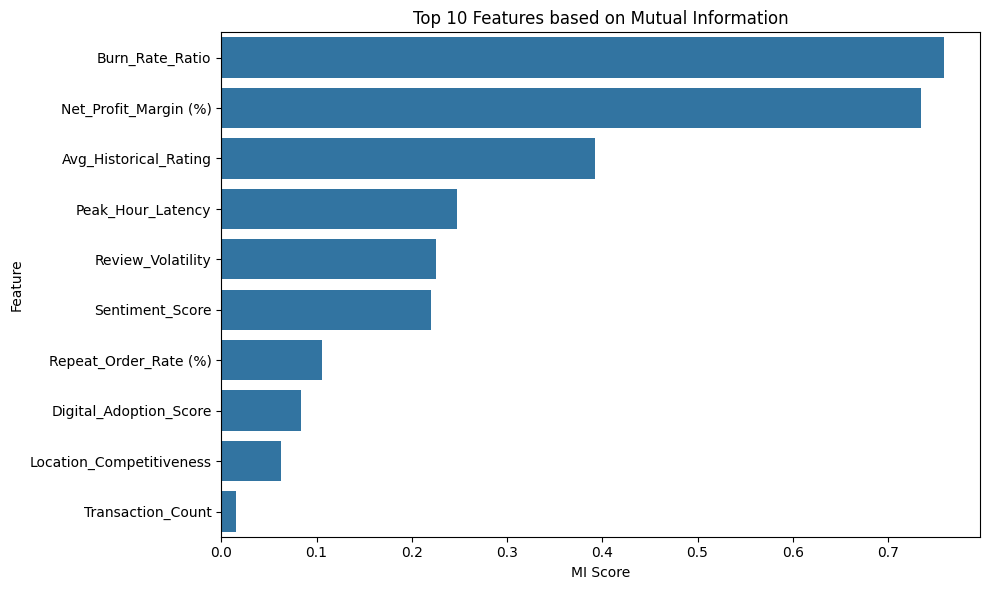

In [16]:
# Analisis hubungan antara fitur dengan target menggunakan Mutual Information
# Memisahkan variabel fitur (X) dan target (y)
X_assesed = df_cleaned.drop(columns=['ID', 'Review_Text', 'Class'])
y_assesed = df_cleaned['Class']

# Melakukan pemilihan fitur dengan tipe data object
categorical_cols = X_assesed.select_dtypes(include='object').columns

# Melakukan encoding manual terhadap fitur kategorikal untuk memastikan bahwa urutannya tidak tertukar
map_peak_hour_latency = {'Low':1,
                         'Med':2,
                         'High':3}

X_assesed["Peak_Hour_Latency"] = X_assesed["Peak_Hour_Latency"].map(map_peak_hour_latency)

# Menambahkan encoding manual untuk Business_Tenure_Months
map_business_tenure = {'Di atas 24 Bulan': 1,
                       'Di bawah 24 Bulan': 0}
X_assesed["Business_Tenure_Months"] = X_assesed["Business_Tenure_Months"].map(map_business_tenure)

# Menghitung nilai Mutual Information antara setiap fitur dengan target
mi_scores = mutual_info_classif(X_assesed, y_assesed, random_state=42)

# Mengubah hasil Mutual Information ke dalam bentuk Series dan mengurutkannya
mi_scores_series = pd.Series(mi_scores, name='Mutual_Information_Score', index=X_assesed.columns)
mi_scores_series = mi_scores_series.sort_values(ascending=False)

# Membuat DataFrame untuk menampilkan hasil Mutual Information secara terstruktur
mi_df = (
    pd.DataFrame({
        'Feature': X_assesed.columns,
        'Mutual_Information_Score': mi_scores
    })
    .sort_values(by='Mutual_Information_Score', ascending=False)
    .reset_index(drop=True)
)

print("Mutual Information Scores with 'Class':")

# Menyimpan pengaturan format tampilan angka saat ini
original_float_format = pd.options.display.float_format

# Mengatur format tampilan angka agar memiliki presisi
pd.options.display.float_format = '{:,.8f}'.format

# Menampilkan DataFrame hasil perhitungan Mutual Information
print(mi_df.to_string())

# Mengembalikan format tampilan angka ke pengaturan semula
pd.options.display.float_format = original_float_format

plt.figure(figsize=(10,6))
sns.barplot(
    x='Mutual_Information_Score',
    y='Feature',
    data=mi_df.head(10)
)

plt.title("Top 10 Features based on Mutual Information")
plt.xlabel("MI Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Berdasarkan hasil analisis Mutual Information, terlihat bahwa fitur dengan kontribusi paling besar dalam menentukan klasifikasi UMKM adalah Burn_Rate_Ratio dan Net_Profit_Margin (%). Hal ini menunjukkan bahwa aspek efisiensi biaya dan profitabilitas merupakan faktor utama yang membedakan performa bisnis antar kelas (Growth, Elite, Critical, dan Struggling).

Selain itu, Avg_Historical_Rating juga memiliki pengaruh yang cukup signifikan, yang mengindikasikan bahwa persepsi pelanggan terhadap kualitas produk atau layanan turut berperan dalam menentukan posisi bisnis.

Fitur operasional seperti Peak_Hour_Latency dan Review_Volatility memberikan kontribusi menengah, menandakan bahwa stabilitas operasional dan konsistensi pengalaman pelanggan juga mempengaruhi klasifikasi, meskipun tidak sebesar faktor finansial.

Sementara itu, fitur seperti Repeat_Order_Rate (%), Digital_Adoption_Score, dan Location_Competitiveness memiliki pengaruh yang relatif lebih kecil. Hal ini menunjukkan bahwa meskipun faktor-faktor tersebut tetap relevan, mereka bukan penentu utama dalam membedakan kelas bisnis.

Secara keseluruhan, hasil ini mengindikasikan bahwa metrik finansial dan efisiensi operasional merupakan indikator paling penting dalam menilai kesiapan investasi suatu UMKM.


Cek Multikolinearitas

In [17]:
X = df_cleaned.select_dtypes(include='number')

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values(by="VIF", ascending = False))

                     feature         VIF
3            Burn_Rate_Ratio  176.927882
5      Avg_Historical_Rating  152.482310
4          Transaction_Count   15.020648
9   Location_Competitiveness   14.554731
6          Review_Volatility   13.521751
7      Repeat_Order_Rate (%)    9.454931
8     Digital_Adoption_Score    9.192708
2      Net_Profit_Margin (%)    8.519054
1            Monthly_Revenue    5.331068
0                         ID    3.991482
10           Sentiment_Score    1.704391



Temuan multikolinearitas yang tinggi pada fitur-fitur utama mengindikasikan bahwa performa UMKM tidak hanya ditentukan oleh satu metrik tunggal, melainkan oleh kombinasi variabel yang saling berkaitan.

Sebagai contoh, tingginya korelasi antara Burn Rate dan variabel lainnya menunjukkan bahwa efisiensi biaya kemungkinan berkaitan erat dengan skala transaksi, profitabilitas, maupun perilaku pelanggan. Hal ini memperkuat bahwa indikator finansial dalam bisnis UMKM cenderung bergerak secara bersamaan (interdependent).

Implikasinya, dalam konteks evaluasi investasi, investor tidak dapat hanya mengandalkan satu metrik, melainkan perlu melihat gambaran holistik dari beberapa indikator yang saling berhubungan

Melihat Hubungan Antar Fitur pada Dataset

In [18]:
categorical_cols = df_cleaned.select_dtypes(include='object').columns
numerical_cols = df_cleaned.select_dtypes(include='number').columns

results = []

for cat_col in categorical_cols:
    for num_col in numerical_cols:
        groups = df_cleaned.groupby(cat_col)[num_col].apply(list)

        # Pastikan tiap grup ada datanya
        if len(groups) > 1:
            f_stat, p_value = f_oneway(*groups)
            results.append((cat_col, num_col, f_stat, p_value))


anova_df = pd.DataFrame(results, columns=['Categorical', 'Numerical', 'F_stat', 'p_value'])

# Ambil yang signifikan
anova_df = anova_df[anova_df['p_value'] < 0.05].sort_values(by='F_stat', ascending=False)

print(anova_df)

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


               Categorical                 Numerical        F_stat  \
10             Review_Text           Sentiment_Score           inf   
28       Peak_Hour_Latency         Review_Volatility  1.675108e+05   
35                   Class     Net_Profit_Margin (%)  1.242532e+05   
36                   Class           Burn_Rate_Ratio  1.233246e+05   
32       Peak_Hour_Latency           Sentiment_Score  6.044778e+04   
38                   Class     Avg_Historical_Rating  5.486685e+04   
25       Peak_Hour_Latency           Burn_Rate_Ratio  5.446659e+04   
24       Peak_Hour_Latency     Net_Profit_Margin (%)  5.207882e+04   
27       Peak_Hour_Latency     Avg_Historical_Rating  4.704649e+04   
15  Business_Tenure_Months         Transaction_Count  3.861514e+04   
39                   Class         Review_Volatility  2.927852e+04   
43                   Class           Sentiment_Score  1.616855e+04   
12  Business_Tenure_Months           Monthly_Revenue  1.081654e+04   
30       Peak_Hour_L


Berdasarkan hasil uji ANOVA, ditemukan bahwa sebagian besar kombinasi variabel kategorikal dan numerikal memiliki perbedaan yang signifikan secara statistik (p-value < 0.05). Hal ini menunjukkan bahwa variabel kategorikal dalam dataset berperan dalam membedakan karakteristik performa UMKM.

Secara khusus, variabel Class menunjukkan pengaruh yang sangat signifikan terhadap berbagai indikator utama seperti Net_Profit_Margin (%), Burn_Rate_Ratio, Avg_Historical_Rating, dan Review_Volatility. Hal ini mengindikasikan bahwa klasifikasi UMKM (Growth, Elite, Critical, Struggling)  merepresentasikan perbedaan performa bisnis yang nyata, baik dari aspek finansial maupun operasional.

Selain itu, variabel Peak_Hour_Latency juga menunjukkan pengaruh signifikan terhadap banyak fitur seperti Review_Volatility, Sentiment_Score, dan Net_Profit_Margin (%). Ini menunjukkan bahwa faktor operasional, khususnya performa sistem pada jam sibuk, memiliki keterkaitan erat dengan stabilitas dan persepsi pelanggan.

Variabel Business_Tenure_Months juga berpengaruh signifikan terhadap metrik seperti Transaction_Count dan Monthly_Revenue, yang menunjukkan bahwa umur bisnis berkontribusi terhadap skala dan aktivitas operasional UMKM.

Secara keseluruhan, hasil ini memperkuat bahwa perbedaan antar segmen UMKM tidak bersifat kebetulan, melainkan didukung oleh perbedaan signifikan pada berbagai indikator kunci bisnis

# Visualisasi / Explanatory Data Analysis

Pertanyaan 1

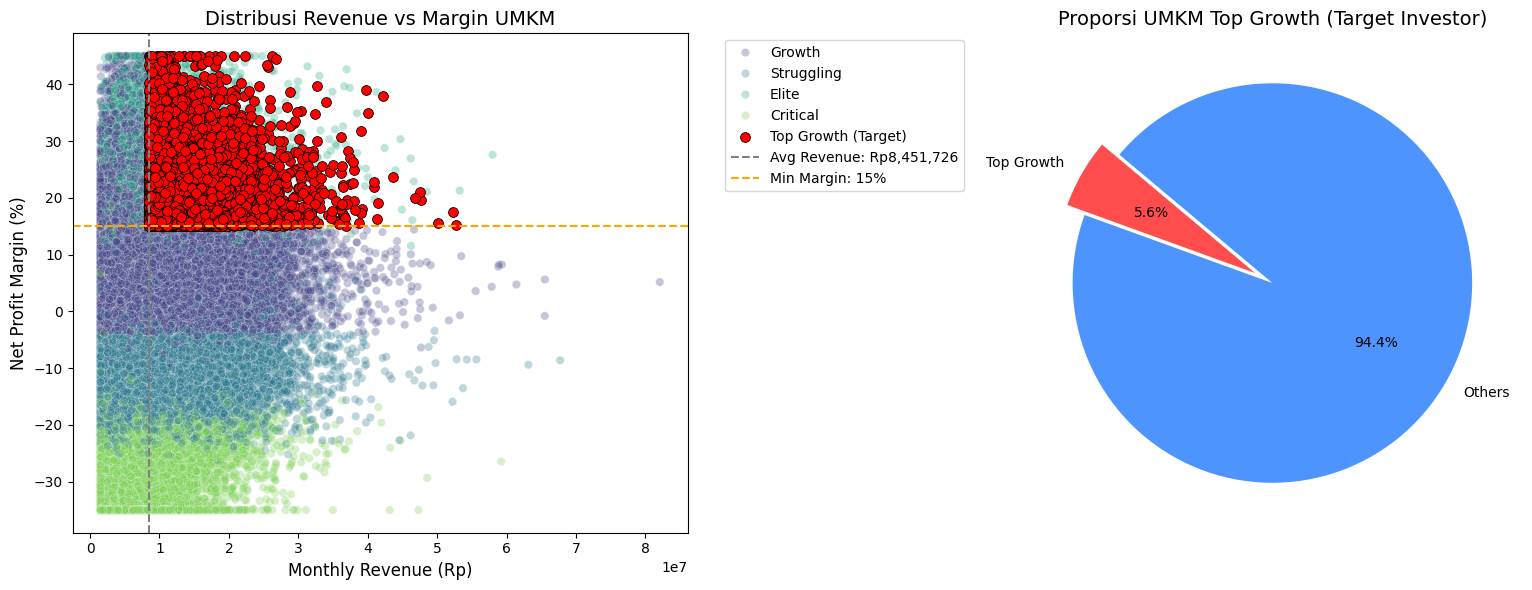

Rata-rata Monthly Revenue: Rp8,451,726.38
Jumlah UMKM Top Growth: 8369 UMKM


In [19]:
# 2. Membuat Layout Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Visualisasi A: Scatter Plot (Revenue vs Margin)
sns.scatterplot(data=df_cleaned, x='Monthly_Revenue', y='Net_Profit_Margin (%)',
                hue='Class', alpha=0.3, ax=ax1, palette='viridis')
sns.scatterplot(data=top_growth, x='Monthly_Revenue', y='Net_Profit_Margin (%)',
                color='red', label='Top Growth (Target)', ax=ax1, s=50, edgecolor='black')

# Menambahkan garis ambang batas (Threshold)
ax1.axvline(avg_revenue, color='gray', linestyle='--', label=f'Avg Revenue: Rp{avg_revenue:,.0f}')
ax1.axhline(15, color='orange', linestyle='--', label='Min Margin: 15%')

ax1.set_title('Distribusi Revenue vs Margin UMKM', fontsize=14)
ax1.set_xlabel('Monthly Revenue (Rp)', fontsize=12)
ax1.set_ylabel('Net Profit Margin (%)', fontsize=12)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Visualisasi B: Pie Chart (Proporsi Target)
labels = ['Top Growth', 'Others']
counts = [len(top_growth), len(df_cleaned) - len(top_growth)]
ax2.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#ff4d4d', '#4d94ff'], explode=(0.1, 0))
ax2.set_title('Proporsi UMKM Top Growth (Target Investor)', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Rata-rata Monthly Revenue: Rp{avg_revenue:,.2f}")
print(f"Jumlah UMKM Top Growth: {len(top_growth)} UMKM")


Visualisasi scatter plot menunjukkan bahwa sebagian besar UMKM dalam dataset ini masih beroperasi dengan pendapatan bulanan yang berada di bawah atau di sekitar rata-rata Rp8,45 juta, namun terdapat kelompok elit yang berhasil menonjol di kuadran kanan atas. Kelompok Top Growth ini, yang hanya mencakup sekitar 5,6% dari total populasi, merupakan segmen yang paling menarik bagi investor karena mampu membuktikan skalabilitas bisnis yang sehat; mereka tidak hanya memiliki pendapatan di atas rata-rata tetapi juga mempertahankan margin laba bersih di atas 15%. Hal ini mengindikasikan bahwa model operasional mereka cukup efisien untuk menangani volume transaksi yang besar tanpa tergerus oleh biaya tambahan yang biasanya muncul saat bisnis berekspansi.

Dari sisi proporsi, dominasi kelompok "Others" sebesar 94,4% menggarisbawahi tantangan besar yang dihadapi UMKM pada umumnya untuk mencapai titik keseimbangan antara pertumbuhan pendapatan dan profitabilitas tinggi. Bagi investor, data ini berfungsi sebagai filter strategis untuk memitigasi risiko dengan cara memprioritaskan UMKM yang memiliki "titik merah" pada grafik, karena mereka telah melewati ambang batas efisiensi modal (burn rate yang terjaga) dan memiliki daya terima pasar yang kuat. Secara keseluruhan, grafik ini memberikan bukti visual bahwa adopsi strategi berbasis data dapat membantu memisahkan bisnis yang sekadar bertahan hidup dengan bisnis yang memiliki potensi return on investment (ROI) tinggi.


Pertanyaan 2

/tmp/ipykernel_6875/644675778.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


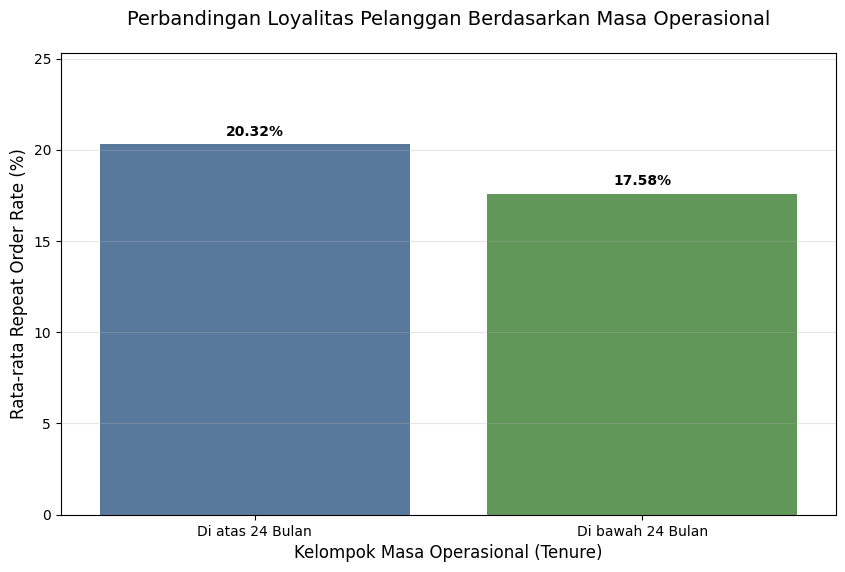

In [20]:
# Menyiapkan data untuk visualisasi
plt.figure(figsize=(10, 6))

# Membuat Bar Chart
ax = sns.barplot(
    x='Business_Tenure_Months',
    y='Repeat_Order_Rate (%)',
    data=tenure_comparison,
    palette=['#4e79a7', '#59a14f'],
    order=['Di atas 24 Bulan', 'Di bawah 24 Bulan']
)

# Menambahkan label angka di atas bar agar lebih informatif
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontweight='bold')

# Menambah judul dan label sumbu
plt.title('Perbandingan Loyalitas Pelanggan Berdasarkan Masa Operasional', fontsize=14, pad=20)
plt.xlabel('Kelompok Masa Operasional (Tenure)', fontsize=12)
plt.ylabel('Rata-rata Repeat Order Rate (%)', fontsize=12)
plt.ylim(0, tenure_comparison['Repeat_Order_Rate (%)'].max() + 5)
plt.grid(axis='y', alpha=0.3)

plt.show()

Berdasarkan visualisasi tersebut, terdapat perbedaan yang konsisten antara UMKM senior dan junior dalam hal loyalitas pelanggan. UMKM yang telah beroperasi di atas 24 bulan mencatatkan rata-rata Repeat Order Rate sebesar 20,32%, yang mana angka ini lebih tinggi dibandingkan UMKM dengan masa operasional di bawah 24 bulan yang berada di angka 17,59%.

Hal ini memberikan insight strategis bagi investor bahwa kematangan operasional atau "jam terbang" berbanding lurus dengan kemampuan bisnis dalam mempertahankan basis pelanggannya. UMKM yang sudah melewati ambang batas dua tahun cenderung memiliki sistem pelayanan, kualitas produk yang lebih konsisten, serta brand awareness yang lebih kuat di mata konsumen dibandingkan pelaku usaha baru. Meskipun demikian, angka retensi pada UMKM junior tetap menunjukkan potensi yang kompetitif bagi bisnis yang sedang berkembang, memberikan sinyal bahwa investasi pada tahap awal tetap menjanjikan jika didukung dengan strategi pengembangan loyalitas yang tepat.

Pertanyaan 3

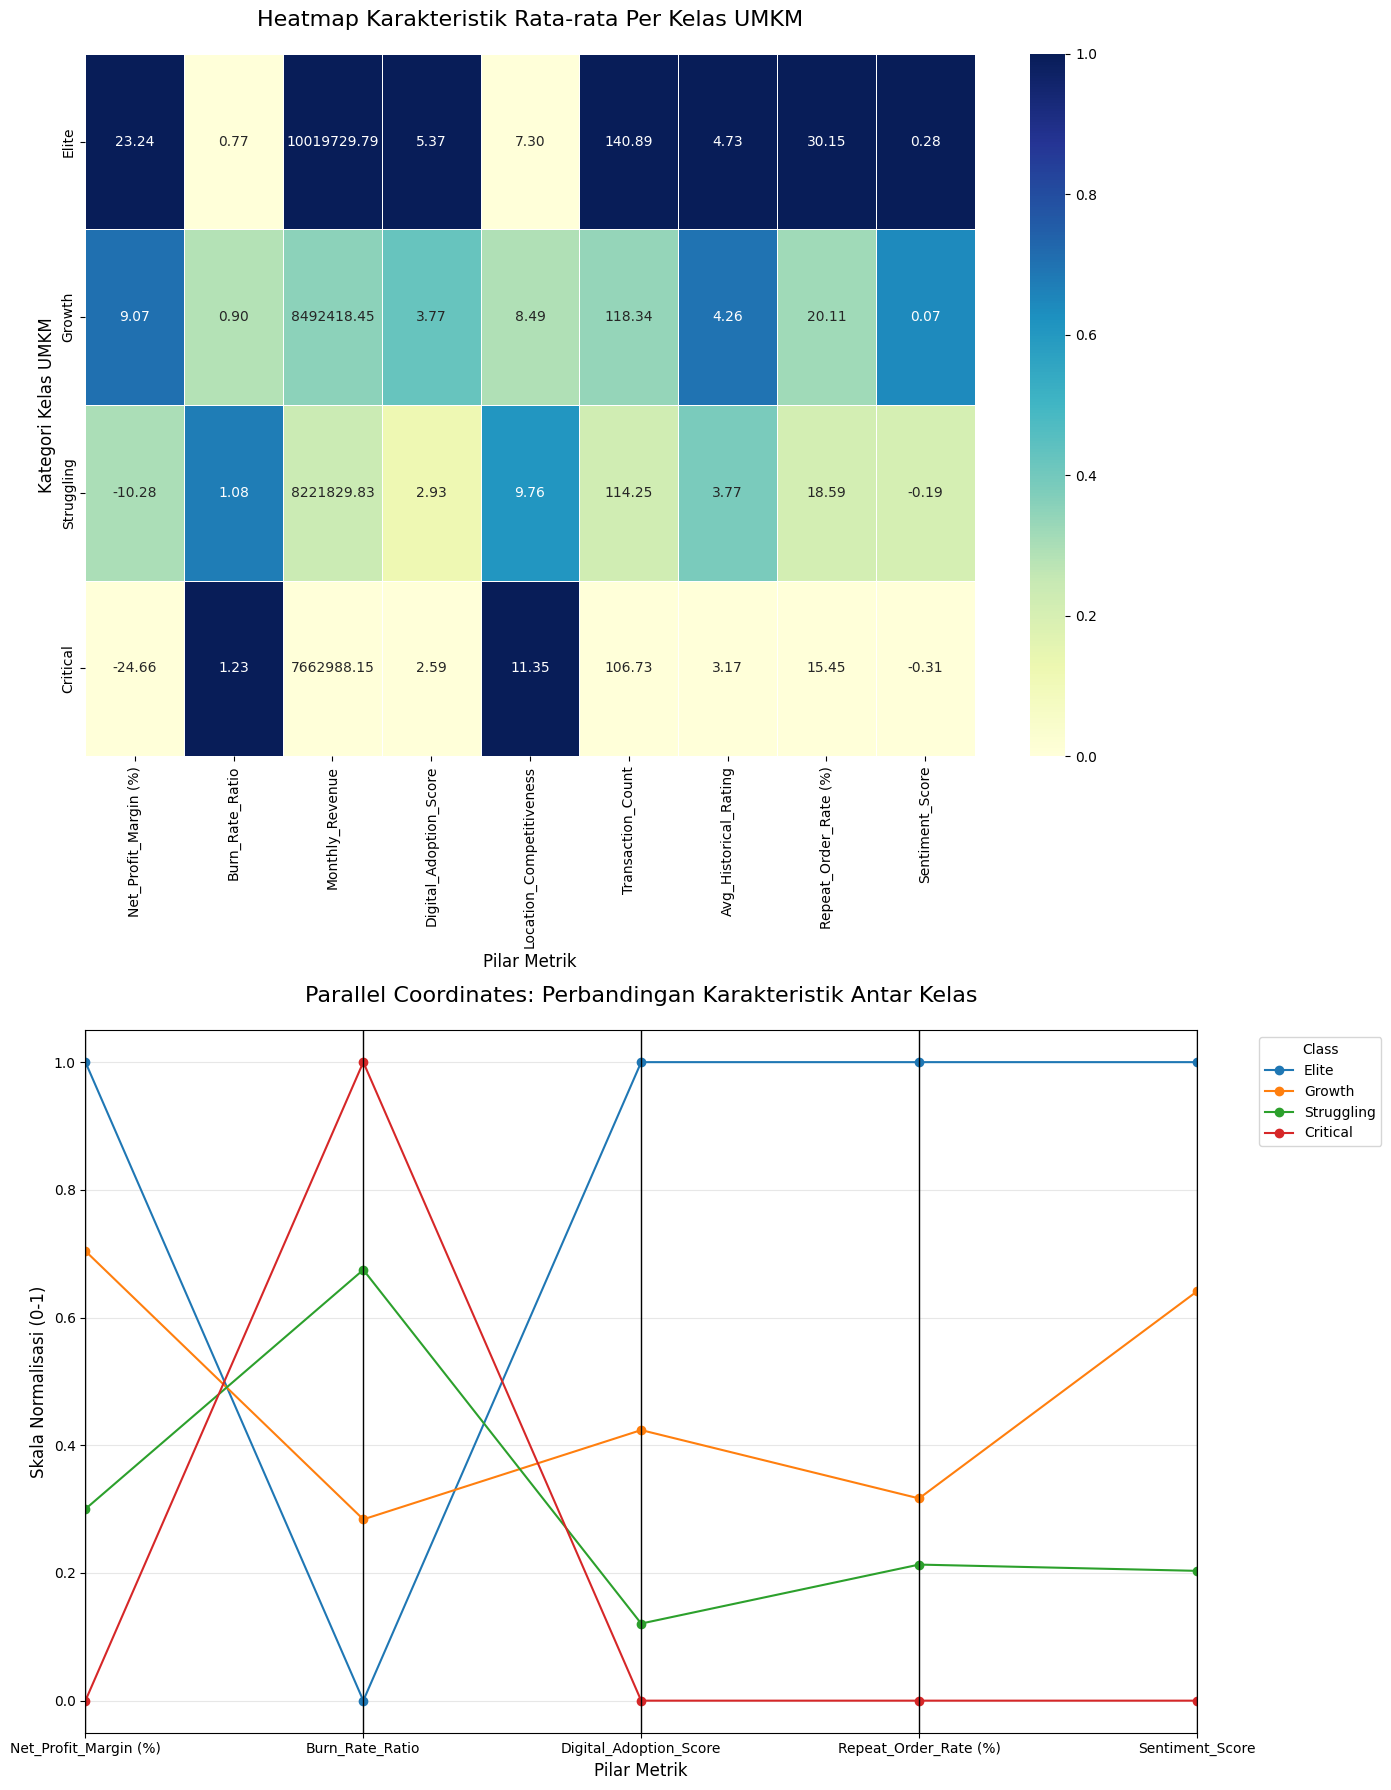

In [21]:
# 1. Menentukan pilar metrik
financial_metrics = ['Net_Profit_Margin (%)', 'Burn_Rate_Ratio', 'Monthly_Revenue']
operational_metrics = ['Digital_Adoption_Score', 'Location_Competitiveness', 'Transaction_Count']
behavior_metrics = ['Avg_Historical_Rating', 'Repeat_Order_Rate (%)', 'Sentiment_Score']
all_metrics = financial_metrics + operational_metrics + behavior_metrics

# 2. Membuat tabel profil rata-rata per Kelas
class_profiling = df_cleaned.groupby('Class')[all_metrics].mean()
class_profiling = class_profiling.sort_values(by='Net_Profit_Margin (%)', ascending=False)

# Normalisasi data untuk perbandingan skala
class_profiling_norm = (class_profiling - class_profiling.min()) / (class_profiling.max() - class_profiling.min())

# 3. Membuat Visualisasi Atas-Bawah (Heatmap & Coordinates)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 18))

# --- VISUALISASI 1: HEATMAP ---
sns.heatmap(class_profiling_norm, annot=class_profiling, fmt=".2f", cmap="YlGnBu", linewidths=.5, ax=ax1)
ax1.set_title('Heatmap Karakteristik Rata-rata Per Kelas UMKM', fontsize=16, pad=20)
ax1.set_xlabel('Pilar Metrik', fontsize=12)
ax1.set_ylabel('Kategori Kelas UMKM', fontsize=12)

# --- VISUALISASI 2: PARALLEL COORDINATES CHART ---
# Memilih metrik representatif untuk grafik koordinat
coord_metrics = ['Net_Profit_Margin (%)', 'Burn_Rate_Ratio', 'Digital_Adoption_Score', 'Repeat_Order_Rate (%)', 'Sentiment_Score']
df_parallel = class_profiling_norm[coord_metrics].reset_index()

pd.plotting.parallel_coordinates(df_parallel, 'Class',
                                 color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
                                 marker='o', ax=ax2)

ax2.set_title('Parallel Coordinates: Perbandingan Karakteristik Antar Kelas', fontsize=16, pad=20)
ax2.set_ylabel('Skala Normalisasi (0-1)', fontsize=12)
ax2.set_xlabel('Pilar Metrik', fontsize=12)
ax2.grid(alpha=0.3)
ax2.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Berdasarkan visualisasi Heatmap dan Radar Chart di atas, kita dapat menyimpulkan bahwa setiap kelas UMKM memiliki "DNA" performa yang sangat berbeda dan terukur secara signifikan. Kelompok Elite muncul sebagai standar tertinggi dengan keunggulan mutlak di seluruh pilar, di mana adopsi teknologi yang tinggi (skor 5.37) berbanding lurus dengan efisiensi modal yang sangat baik dan loyalitas pelanggan yang mencapai angka tertinggi (~30%). Di sisi lain, kelompok Growth menunjukkan karakteristik bisnis yang sangat potensial untuk skala besar karena berhasil menjaga margin profit tetap positif di tengah volume transaksi yang padat.

Sebaliknya, pada kategori Struggling dan Critical, terlihat pola kegagalan yang bermuara pada inefisiensi operasional, di mana nilai Burn Rate Ratio yang tinggi (>1.0) tidak mampu menghasilkan retensi pelanggan yang stabil. Hal ini memberikan insight krusial bagi investor bahwa UMKM yang mengabaikan adopsi digital dan memiliki ketergantungan tinggi pada biaya operasional tanpa diimbangi kualitas layanan (sentimen rendah) cenderung memiliki risiko kegagalan yang tinggi. Bagi Anda, data ini membuktikan bahwa strategi paling efektif untuk menaikkan kelas UMKM adalah dengan mendorong efisiensi modal dan digitalisasi guna menciptakan ekosistem bisnis yang lebih sehat dan menarik bagi pendanaan lebih lanjut.

# Conclution

Pertanyaan 1


dapat disimpulkan bahwa strategi investasi yang paling optimal adalah dengan berfokus pada kelompok Top Growth yang hanya mencakup 5,6% dari total populasi UMKM. Kelompok ini merupakan "mutiara" yang berhasil memenuhi kriteria ketat, yaitu memiliki margin laba bersih di atas 15% dan pendapatan bulanan yang melampaui rata-rata keseluruhan sebesar Rp8.451.726,38. Titik-titik merah pada scatter plot menunjukkan bahwa unit usaha ini memiliki fundamental keuangan yang sangat sehat karena mampu mempertahankan profitabilitas tinggi meskipun skalanya sudah membesar. Sebaliknya, dominasi 94,4% UMKM lainnya pada pie chart mengindikasikan bahwa sebagian besar pelaku usaha masih berjuang untuk mencapai titik keseimbangan antara pertumbuhan volume transaksi dan efisiensi margin. Oleh karena itu, bagi investor, data ini menjadi panduan krusial untuk memitigasi risiko dengan cara memprioritaskan modal pada segmen kecil yang sudah terbukti memiliki model bisnis yang scalable dan berkelanjutan.

Pertanyaan 2

Analisis perbandingan menunjukkan bahwa masa operasional bisnis memiliki pengaruh positif terhadap loyalitas pelanggan, di mana UMKM yang telah beroperasi di atas 24 bulan mencatatkan rata-rata Repeat Order Rate yang lebih tinggi, yakni sebesar 20,32%. Angka ini menunjukkan performa yang lebih stabil dibandingkan dengan UMKM yang baru beroperasi di bawah 24 bulan, yang memiliki rata-rata pesanan berulang sebesar 17,58%. Perbedaan ini mengindikasikan bahwa seiring dengan bertambahnya usia bisnis, UMKM cenderung berhasil membangun kepercayaan konsumen, memperkuat brand awareness, dan menyempurnakan kualitas layanan mereka sehingga mampu mempertahankan pelanggan lama dengan lebih baik. Bagi investor, data ini memberikan sinyal bahwa UMKM dengan masa operasional yang lebih panjang memiliki risiko retensi yang lebih rendah, namun UMKM muda tetap menunjukkan potensi kompetitif yang cukup kuat untuk terus dikembangkan melalui strategi loyalitas yang tepat.

Pertanyaan 3

Analisis profil karakteristik mengungkapkan perbedaan "DNA" bisnis yang sangat kontras di antara keempat kelas UMKM, di mana efisiensi operasional dan adopsi teknologi menjadi pembeda utama keberhasilan sebuah unit usaha. Kelompok Elite muncul sebagai standar emas dengan performa unggul di seluruh pilar, mencatatkan Net Profit Margin tertinggi (23,24%) dan tingkat loyalitas pelanggan mencapai 30,15%, yang didukung oleh skor adopsi digital tertinggi (5,37). Sebaliknya, kelompok Critical berada dalam kondisi risiko tinggi dengan margin profit negatif terdalam (-24,66%) dan ketergantungan ekstrem pada pembakaran modal, sebagaimana ditunjukkan oleh lonjakan Burn Rate Ratio mencapai 1,23 pada grafik koordinat paralel.

Sementara itu, kelas Growth menunjukkan karakteristik bisnis yang sehat dan scalable dengan margin positif (9,07%) serta retensi pelanggan yang stabil, menjadikannya target potensial untuk didorong menjadi kelas Elite melalui peningkatan digitalisasi. Di sisi lain, kelas Struggling terjebak dalam inefisiensi biaya operasional yang mulai menggerus keuntungan. Secara keseluruhan, visualisasi ini membuktikan bahwa UMKM yang sukses tidak hanya mengandalkan pendapatan besar, tetapi mengombinasikan adopsi teknologi tinggi dengan manajemen biaya yang ketat (low burn rate) untuk menciptakan loyalitas pelanggan yang berkelanjutan. Bagi investor, pola ini memberikan navigasi yang jelas: prioritas modal harus diarahkan pada bisnis yang mampu menjaga burn rate tetap rendah namun memiliki repeat order dan skor digital yang terus meningkat.

# Data Dictionary

In [22]:
# Menyiapkan informasi dasar kolom
data_dict = pd.DataFrame({
    'Nama Kolom': df_cleaned.columns,
    'Tipe Data': df_cleaned.dtypes.values,
    'Jumlah Nilai Unik': [df_cleaned[col].nunique() for col in df_cleaned.columns],
    'Contoh Nilai': [df_cleaned[col].iloc[0] for col in df_cleaned.columns]
})

# Menambahkan deskripsi manual sesuai konteks bisnis UMKM
descriptions = {
    'ID': 'Identitas unik untuk setiap UMKM',
    'Monthly_Revenue': 'Total pendapatan kotor UMKM dalam satu bulan (Rupiah)',
    'Net_Profit_Margin (%)': 'Persentase keuntungan bersih setelah dikurangi semua biaya operasional',
    'Burn_Rate_Ratio': 'Rasio biaya pengeluaran dibandingkan pendapatan (Efisiensi modal)',
    'Transaction_Count': 'Jumlah total transaksi yang terjadi dalam satu bulan',
    'Avg_Historical_Rating': 'Rata-rata penilaian bintang dari pelanggan (skala 1-5)',
    'Review_Text': 'Kumpulan teks ulasan atau feedback dari pelanggan',
    'Review_Volatility': 'Tingkat variasi atau fluktuasi emosi dalam ulasan pelanggan',
    'Business_Tenure_Months': 'Lama UMKM telah beroperasi (dalam satuan bulan)',
    'Repeat_Order_Rate (%)': 'Persentase pelanggan yang melakukan pembelian lebih dari satu kali',
    'Digital_Adoption_Score': 'Skor kesiapan dan penggunaan teknologi digital (skala 1-10)',
    'Peak_Hour_Latency': 'Tingkat keterlambatan layanan pada jam sibuk (Low/Med/High)',
    'Location_Competitiveness': 'Tingkat persaingan bisnis di lokasi geografis UMKM tersebut',
    'Sentiment_Score': 'Analisis sentimen ulasan pelanggan (-1 hingga 1)',
    'Class': 'Kategorisasi performa UMKM (Elite, Growth, Struggling, Critical)'
}

data_dict['Deskripsi'] = data_dict['Nama Kolom'].map(descriptions)

# Menampilkan Data Dictionary
print("=== Data Dictionary UMKM Dashboard ===")
data_dict[['Nama Kolom', 'Deskripsi', 'Tipe Data', 'Jumlah Nilai Unik', 'Contoh Nilai']]

=== Data Dictionary UMKM Dashboard ===


,Nama Kolom,Deskripsi,Tipe Data,Jumlah Nilai Unik,Contoh Nilai
0,ID,Identitas unik untuk setiap UMKM,int64,150000,1
1,Monthly_Revenue,Total pendapatan kotor UMKM dalam satu bulan (...,float64,147293,6680716.0
2,Net_Profit_Margin (%),Persentase keuntungan bersih setelah dikurangi...,float64,7650,22.72
3,Burn_Rate_Ratio,Rasio biaya pengeluaran dibandingkan pendapata...,float64,988,0.811
4,Transaction_Count,Jumlah total transaksi yang terjadi dalam satu...,float64,262,161.0
5,Avg_Historical_Rating,Rata-rata penilaian bintang dari pelanggan (sk...,float64,351,4.75
6,Review_Text,Kumpulan teks ulasan atau feedback dari pelanggan,object,45139,"Transaksi digital lancar, proses checkout tida..."
7,Review_Volatility,Tingkat variasi atau fluktuasi emosi dalam ula...,float64,867,0.313
8,Business_Tenure_Months,Lama UMKM telah beroperasi (dalam satuan bulan),object,2,Di atas 24 Bulan
9,Repeat_Order_Rate (%),Persentase pelanggan yang melakukan pembelian ...,float64,4313,19.4


## AB Testing

In [23]:
# --- A/B TESTING SECTION ---
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 1. Menyiapkan Data Kelompok
# Kita asumsikan skor > 5 adalah adopsi digital tinggi
group_a = df_cleaned[df_cleaned['Digital_Adoption_Score'] <= 5]['Monthly_Revenue']
group_b = df_cleaned[df_cleaned['Digital_Adoption_Score'] > 5]['Monthly_Revenue']

# 2. Statistik Deskriptif
print(f"Rata-rata Pendapatan Kelompok A (Digital Rendah): Rp{group_a.mean():,.2f}")
print(f"Rata-rata Pendapatan Kelompok B (Digital Tinggi): Rp{group_b.mean():,.2f}")
print("-" * 50)

# 3. Uji Hipotesis (T-Test Independent)
# Hipotesis Nol (H0): Tidak ada perbedaan pendapatan antara kedua kelompok
# Hipotesis Alternatif (H1): Ada perbedaan pendapatan yang signifikan
t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# 4. Interpretasi Hasil
alpha = 0.05
if p_value < alpha:
    print("Kesimpulan: Tolak Hipotesis Nol (Signifikan).")
    print("Terdapat perbedaan pendapatan yang nyata antara UMKM digital tinggi dan rendah.")
else:
    print("Kesimpulan: Gagal Tolak Hipotesis Nol (Tidak Signifikan).")
    print("Tidak ada bukti cukup bahwa adopsi digital mempengaruhi pendapatan secara drastis.")



Rata-rata Pendapatan Kelompok A (Digital Rendah): Rp8,066,171.91
Rata-rata Pendapatan Kelompok B (Digital Tinggi): Rp10,017,226.85
--------------------------------------------------
T-statistic: -53.3205
P-value: 0.0000e+00
Kesimpulan: Tolak Hipotesis Nol (Signifikan).
Terdapat perbedaan pendapatan yang nyata antara UMKM digital tinggi dan rendah.


# Feature Engineering

Setelah berunding dengan tim AI, kami memutuskan untuk melakukan beberapa hal berikut

## Melakukan Drop Fitur Dengan VIF dan Multikolinearitas Tinggi

In [24]:
df_cleaned = df_cleaned.drop(columns=['Burn_Rate_Ratio', 'Transaction_Count', 'Location_Competitiveness'])



In [25]:
df_cleaned = df_cleaned.drop('Sentiment_Score', axis=1)

## Melakukan Perbaikan Pada Format Penamaan Fitur

In [26]:
# Mengubah seluruh nama kolom pada dataset menjadi huruf kecil (lowercase)
df_cleaned.columns = df_cleaned.columns.str.lower().str.replace('(%)', '').str.strip()

# Melakukan rename penamaan kolom
df_cleaned = df_cleaned.rename(columns={'avg_historical_rating': 'kepuasan_pelanggan'})

# Tampilkan seluruh nama kolom
print(df_cleaned.columns)

Index(['id', 'monthly_revenue', 'net_profit_margin', 'kepuasan_pelanggan',
       'review_text', 'review_volatility', 'business_tenure_months',
       'repeat_order_rate', 'digital_adoption_score', 'peak_hour_latency',
       'class'],
      dtype='object')


## Melakukan Finalisasi Pemilihan Fitur Berdasarkan MI

In [27]:
df_cleaned = df_cleaned[[
    'net_profit_margin',
    'kepuasan_pelanggan',
    'peak_hour_latency',
    'review_volatility',
    'repeat_order_rate',
    'digital_adoption_score',
    'monthly_revenue',
    'business_tenure_months',
    'class'
]]

## Mengedit beberapa Fitur

In [28]:

# Mengubah business tenure months menjadi tahun
# 2. Buat kolom numerik asli sebelum diubah menjadi string pada tahapan sebelumnya
# Pastikan kita mengambil angka saja atau menggunakan data asli sebelum konversi string,
# atau mengekstrak angka dari string yang ada
df_cleaned['business_tenure_months_numeric'] = df['Business_Tenure_Months']

# 3. Hitung business_tenure_years menggunakan data numerik
df_cleaned['business_tenure_years'] = df_cleaned['business_tenure_months_numeric'] / 12

# 4. Buat year_revenue dengan operasi yang aman
df_cleaned['year_revenue'] = df_cleaned['monthly_revenue'] * 12

# 5. Tampilkan beberapa baris untuk verifikasi
print(df_cleaned[['monthly_revenue', 'year_revenue', 'business_tenure_years']].head())

   monthly_revenue  year_revenue  business_tenure_years
0        6680716.0    80168592.0               8.750000
1        5819101.0    69829212.0               7.916667
2        5236404.0    62836848.0               1.416667
3        8043552.0    96522624.0               9.083333
4        6071256.0    72855072.0               6.166667


In [29]:
df_cleaned.head()

,net_profit_margin,kepuasan_pelanggan,peak_hour_latency,review_volatility,repeat_order_rate,digital_adoption_score,monthly_revenue,business_tenure_months,class,business_tenure_months_numeric,business_tenure_years,year_revenue
0,22.72,4.75,Low,0.313,19.40,4.24,6680716.0,Di atas 24 Bulan,Growth,105,8.750000,80168592.0
1,4.46,4.21,Med,0.632,14.87,1.27,5819101.0,Di atas 24 Bulan,Growth,95,7.916667,69829212.0
2,-10.12,3.51,Med,0.470,21.00,3.37,5236404.0,Di bawah 24 Bulan,Struggling,17,1.416667,62836848.0
3,0.04,4.33,Low,0.206,30.62,5.41,8043552.0,Di atas 24 Bulan,Growth,109,9.083333,96522624.0
4,4.22,4.34,Low,0.232,20.87,2.67,6071256.0,Di atas 24 Bulan,Growth,74,6.166667,72855072.0


# Splitting Dataset

In [30]:
# Memilih fitur dengan hubungan terkuat dengan target
cols_to_select = ['net_profit_margin', 'kepuasan_pelanggan', 'peak_hour_latency', 'review_volatility', 'repeat_order_rate', 'digital_adoption_score', 'year_revenue', 'business_tenure_years']

# Memisahkan X dan y
X = df_cleaned[cols_to_select]
y = df_cleaned['class']

# Melakukan proses splitting dataset training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Melakukan proses splitting dataset training menjadi training dan validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [31]:
# Melihat dimensi masing masing data training dan testing
print("Dimensi data training : ", X_train.shape)
print("Dimensi data validasi : ", X_val.shape)
print("Dimensi data testing : ", X_test.shape)

Dimensi data training :  (96000, 8)
Dimensi data validasi :  (24000, 8)
Dimensi data testing :  (30000, 8)


In [32]:
log_scale_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', RobustScaler())
])

num_cols = X_train.select_dtypes(include='number').columns.tolist()
num_cols.remove('year_revenue')

preprocessor = ColumnTransformer(
    transformers=[
        ('log_scaled', log_scale_pipeline, ['year_revenue']),

        ('peak_encoder',
         OrdinalEncoder(
             categories=[['low', 'medium', 'high']],
             handle_unknown='use_encoded_value',
             unknown_value=-1
         ),
         ['peak_hour_latency']
        ),

        ('scaler',
         RobustScaler(),
         num_cols
        )
    ],
    remainder='passthrough'
)

X_train_clean = preprocessor.fit_transform(X_train)
X_val_clean = preprocessor.transform(X_val)
X_test_clean = preprocessor.transform(X_test)

# Melakukan Log Transform, Encoding, Scaling Pada Dataset

In [33]:
log_scale_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', RobustScaler())
])

num_cols = X_train.select_dtypes(include='number').columns.tolist()
num_cols.remove('year_revenue')

preprocessor = ColumnTransformer(
    transformers=[
        ('log_scaled', log_scale_pipeline, ['year_revenue']),

        ('peak_encoder',
         OrdinalEncoder(
             categories=[['low', 'medium', 'high']],
             handle_unknown='use_encoded_value',
             unknown_value=-1
         ),
         ['peak_hour_latency']
        ),

        ('scaler',
         RobustScaler(),
         num_cols
        )
    ],
    remainder='passthrough'
)

X_train_clean = preprocessor.fit_transform(X_train)
X_val_clean = preprocessor.transform(X_val)
X_test_clean = preprocessor.transform(X_test)

In [34]:
label_mapping = {
    "Critical": 0,
    "Struggling": 1,
    "Growth": 2,
    "Elite": 3
}

# Melakukan encoding terhadap fitur y
y_train_encoded = y_train.map(label_mapping)
y_val_encoded = y_val.map(label_mapping)
y_test_encoded = y_test.map(label_mapping)

# Buat inverses mapping agar bisa mengkonversi kembali
inverse_mapping = {v: k for k, v in label_mapping.items()}

# Melihat hasil encoding
print("y_train :", y_train_encoded.unique())
print("y_val_encoded :", y_val_encoded.unique())
print("y_test_encoded :", y_test_encoded.unique())

y_train : [3 2 1 0]
y_val_encoded : [2 3 1 0]
y_test_encoded : [2 0 1 3]


In [35]:
# Menggabungkan preprocessor dan label encoder ke dalam satu pipeline
pipeline_bundle = {
    "preprocessor": preprocessor,
    "inverse_mapping": inverse_mapping,
    "label_mapping": label_mapping
}

# Menyimpan pipeline ke file .joblib
joblib.dump(pipeline_bundle, "pipeline.joblib", compress=3, protocol=4)

['pipeline.joblib']

In [36]:
# Mengambil OrdinalEncoder dari preprocessor
ordinal_encoder_peak = preprocessor.named_transformers_['peak_encoder']

# Menampilkan mapping kategori untuk kolom kategorikal
print("Category Mappings from OrdinalEncoder:")
print("peak_hour_latency:")
for j, category in enumerate(ordinal_encoder_peak.categories_[0]):
    print(f"  {category} -> {j}")
print("\n")

# Menampilkan mapping label untuk target (y)
print("Class Label Mapping")

# Mencetak dengan format {angka} -> {Nama Kelas}
for class_name, encoded_value in label_mapping.items():
    print(f"  {encoded_value} -> {class_name}")

Category Mappings from OrdinalEncoder:
peak_hour_latency:
  low -> 0
  medium -> 1
  high -> 2


Class Label Mapping
  0 -> Critical
  1 -> Struggling
  2 -> Growth
  3 -> Elite


In [37]:
# Menggabungkan fitur (X) dan target (y) untuk masing-masing subset data
train_df = pd.concat(
    [
        pd.DataFrame(X_train_clean, columns=cols_to_select).reset_index(drop=True),
        pd.Series(y_train_encoded, name='class').reset_index(drop=True)
    ],
    axis=1
)

val_df = pd.concat(
    [
        pd.DataFrame(X_val_clean, columns=cols_to_select).reset_index(drop=True),
        pd.Series(y_val_encoded, name='class').reset_index(drop=True)
    ],
    axis=1
)

test_df = pd.concat(
    [
        pd.DataFrame(X_test_clean, columns=cols_to_select).reset_index(drop=True),
        pd.Series(y_test_encoded, name='class').reset_index(drop=True)
    ],
    axis=1
)

# Menyimpan masing-masing subset dataset ke dalam file CSV sebagai dokumentasi
train_df.to_csv('train.csv', index=False)
val_df.to_csv('val.csv', index=False)
test_df.to_csv('test.csv', index=False)